In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

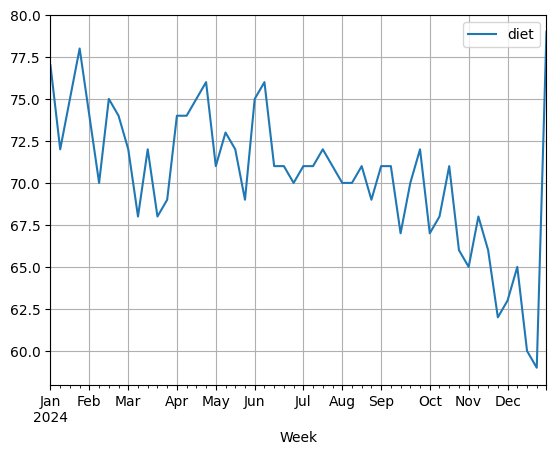

In [2]:
diet = pd.read_csv('../Data/time_series/diet_search.csv', parse_dates = ['Week'], index_col = ['Week'])

# Convert the date index to datetime
diet.index = pd.to_datetime(diet.index)

# Slice the dataset to keep only 2024
diet2024 = diet[diet.index.year == 2024]

# Plot 2014 data
diet2024.plot(grid = True)
plt.show()

In [3]:
stocks = pd.read_csv('../Data/time_series/SP500.csv', parse_dates = ['Date'], index_col = 'Date')
bonds = pd.read_csv('../Data/time_series/US10Y.csv', parse_dates = ['Date'], index_col = 'Date')

# Convert the stock index and bond index into sets
set_stock_dates = set(stocks.index)
set_bond_dates = set(bonds.index)

# Take the difference between the sets and print
print(set_stock_dates - set_bond_dates)

# Merge stocks and bonds DataFrames using join()
stocks_and_bonds = stocks.join(bonds, how = 'inner')
stocks_and_bonds.head()

{Timestamp('2008-10-13 00:00:00'), Timestamp('2025-04-07 00:00:00'), Timestamp('2025-04-08 00:00:00'), Timestamp('2025-04-10 00:00:00'), Timestamp('2015-10-12 00:00:00'), Timestamp('2014-10-13 00:00:00'), Timestamp('2010-10-11 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2025-04-02 00:00:00'), Timestamp('2025-04-04 00:00:00'), Timestamp('2016-11-11 00:00:00'), Timestamp('2025-03-13 00:00:00'), Timestamp('2025-03-18 00:00:00'), Timestamp('2025-04-03 00:00:00'), Timestamp('2025-04-09 00:00:00'), Timestamp('2025-03-28 00:00:00'), Timestamp('2025-04-11 00:00:00'), Timestamp('2010-11-11 00:00:00')}


,SP500,US10Y
Date,,
2026-02-23,6837.75,40.29
2026-02-20,6909.51,40.86
2026-02-19,6861.89,40.75
2026-02-18,6881.31,40.79
2026-02-17,6843.22,40.52


Correlation of stocks and interest rates:  0.3317173596669997


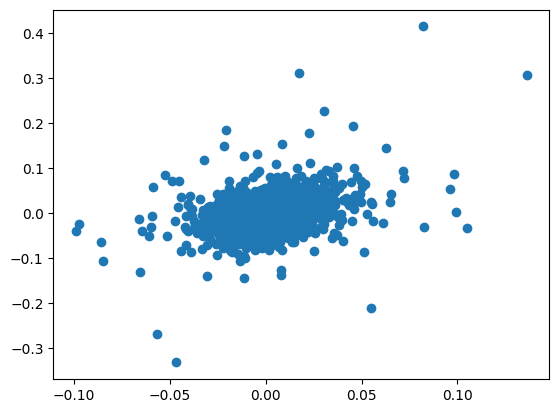

In [4]:
stocks = pd.read_csv('../Data/time_series/SP500.csv', parse_dates = ['Date'], index_col = 'Date')
bonds = pd.read_csv('../Data/time_series/US10Y.csv', parse_dates = ['Date'], index_col = 'Date')

stocks_and_bonds = stocks.join(bonds, how = 'inner')

# Compute percent change using pct_change()
returns = stocks_and_bonds.pct_change()

# Compute correlation using corr()
correlation = returns['SP500'].corr(returns['US10Y'])
print("Correlation of stocks and interest rates: ", correlation)

# Make scatter plot
plt.scatter(returns['SP500'], returns['US10Y'])
plt.show()

In [5]:
df_dji = pd.read_csv('../Data/time_series/DJI.csv', index_col = 'Date', header = 0)
df_ufo = pd.read_csv('../Data/time_series/UFO.csv', index_col = 'Date', header = 0)

levels = pd.DataFrame()
levels['DJI'] = df_dji
levels['UFO'] = df_ufo

# Compute correlation of levels
correlation1 = levels['DJI'].corr(levels['UFO'])
print("Correlation of levels: ", correlation1)

# Compute correlation of percent changes
changes = levels.pct_change()
correlation2 = changes['DJI'].corr(changes['UFO'])
print("Correlation of changes: ", correlation2)

Correlation of levels:  0.9399762210726432
Correlation of changes:  0.06026935462405376


In [6]:
x = pd.Series([1, 2, 3, 4, 5])
y = pd.Series([-2, -4, -6, -8, -10])

# Compute correlation of x and y
correlation = x.corr(y)
print("The correlation between x and y is %4.2f" %(correlation))

# Convert the Series x to a DataFrame and name the column x
dfx = pd.DataFrame(x, columns = ['x'])

# Add a constant to the DataFrame dfx
dfx1 = sm.add_constant(dfx)

# Regress y on dfx1
result = sm.OLS(y, dfx1).fit()

# Print out the results and look at the relationship between R-squared and the correlation above
print(result.summary())

The correlation between x and y is -1.00
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.383e+31
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           4.29e-47
Time:                        16:30:27   Log-Likelihood:                 164.22
No. Observations:                   5   AIC:                            -324.4
Df Residuals:                       3   BIC:                            -325.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

C:\Users\CAguazaco\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [7]:
MSFT = pd.read_csv('../Data/time_series/MSFT.csv', parse_dates = ['Date'], index_col = 'Date')

# Convert the daily data to weekly data
MSFT = MSFT.resample(rule = 'W').last()

# Compute the percentage change of prices
returns = MSFT.pct_change()

# Compute and print the autocorrelation of returns
autocorrelation = returns['Adj Close'].autocorr()
print("The autocorrelation of weekly returns is %4.2f" %(autocorrelation))

The autocorrelation of weekly returns is -0.16


In [8]:
daily_rates = pd.read_csv('../Data/time_series/US10Y.csv', parse_dates = ['Date'], index_col = 'Date')

# Compute the daily change in interest rates 
daily_diff = daily_rates.diff()

# Compute and print the autocorrelation of daily changes
autocorrelation_daily = daily_diff['US10Y'].autocorr()
print("The autocorrelation of daily interest rate changes is %4.2f" %(autocorrelation_daily))

# Convert the daily data to annual data
yearly_rates = daily_rates.resample(rule = 'YE').last()

# Repeat above for annual data
yearly_diff = yearly_rates.diff()
autocorrelation_yearly = yearly_diff['US10Y'].autocorr()
print("The autocorrelation of annual interest rate changes is %4.2f" %(autocorrelation_yearly))

The autocorrelation of daily interest rate changes is -0.01
The autocorrelation of annual interest rate changes is -0.18
